# Notebook 06 — Phase-B Level Scan at SOC = 50%

## Goal

This notebook extends the corrected Tier-0 mechanism fingerprint scan into a single-SOC perturbation-level scan.

The objective is to test whether selected DFN-level perturbations produce monotonic and interpretable drift in ECM-level observables.

This notebook focuses only on SOC = 50%.

## Scientific context

Notebook 05 established that different perturbation families produce separable HPPC fingerprints:

- positive solid diffusion reduction mainly affects relaxation and tau2 descriptors;
- negative exchange-current reduction mainly increases short-window Ri;
- positive exchange-current reduction produces a weaker Ri-sensitive response;
- contact resistance produces a pure ohmic Ri shift when the contact-resistance option is enabled.

The next question is whether these fingerprints scale systematically with perturbation magnitude.

Core mapping:

DFN-level perturbation strength  
→ HPPC waveform deformation  
→ CDEFG / Ri / tau descriptor drift  
→ mechanism-sensitive fingerprint curve

## Perturbation families

This notebook scans four interpretable perturbation families:

1. Positive particle diffusivity scaling:
   - `D_s,p × 1.0`
   - `D_s,p × 0.75`
   - `D_s,p × 0.5`
   - `D_s,p × 0.25`

2. Negative exchange-current density scaling:
   - `j0,n × 1.0`
   - `j0,n × 0.75`
   - `j0,n × 0.5`
   - `j0,n × 0.25`

3. Positive exchange-current density scaling:
   - `j0,p × 1.0`
   - `j0,p × 0.75`
   - `j0,p × 0.5`
   - `j0,p × 0.25`

4. Contact resistance:
   - `0 mΩ`
   - `2.5 mΩ`
   - `5 mΩ`
   - `10 mΩ`

## Workflow

1. Import packages and audit software version and paths.
2. Define shared HPPC protocol at SOC = 50%.
3. Define reusable HPPC runner and observable extraction functions.
4. Build perturbation-level scan cases.
5. Run all cases under consistent model options.
6. Extract:
   - CDEFG points
   - Ri_CD / Ri_EF
   - tau1/tau2 from 60 s and 300 s fitting windows
   - contact overpotential
7. Generate level-response tables and plots.
8. Identify monotonicity, nonlinearity, and weak-response regions.

## Expected outputs

- `data/phaseB_level_scan_soc50_results.csv`
- `data/phaseB_level_scan_soc50_drift_table.csv`
- level-response figures for Ri and tau descriptors
- mechanism-specific fingerprint curves

## Interpretation boundary

This notebook does not model full aging or SOH evolution.

It only evaluates whether selected physical perturbation magnitudes produce systematic observable drift under one SOC and one HPPC protocol.

The correct conclusion format is:

“Under SOC = 50% and the present HPPC protocol, perturbation family X produces observable drift Y.”

This notebook must not claim general aging behavior across all SOC, temperature, or cycling conditions.

In [1]:
# Cell 1 — Imports and path audit（导入库并确认项目路径）

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm

from scipy.optimize import curve_fit

print("PyBaMM version:", pybamm.__version__)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"
FIGURES = ROOT / "figures"

DATA.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

print("ROOT:", ROOT)
print("DATA:", DATA)
print("FIGURES:", FIGURES)

PyBaMM version: 26.3.1
ROOT: /Users/louislu/projects/pybamm-aging-bridge
DATA: /Users/louislu/projects/pybamm-aging-bridge/data
FIGURES: /Users/louislu/projects/pybamm-aging-bridge/figures


In [2]:
# Cell 2 — Shared HPPC configuration（统一 HPPC 协议配置）

SOC_INIT = 0.50
PULSE_C_RATE = "1C"
PULSE_DURATION_S = 10
REST_BEFORE_S = 60
RELAXATION_S = 600
OUTPUT_PERIOD = "0.1 seconds"

COMMON_MODEL_OPTIONS = {
    "contact resistance": "true",
}

print("Shared HPPC configuration")
print("SOC_INIT:", SOC_INIT)
print("Pulse:", PULSE_C_RATE, "for", PULSE_DURATION_S, "s")
print("Rest before pulse:", REST_BEFORE_S, "s")
print("Relaxation:", RELAXATION_S, "s")
print("Output period:", OUTPUT_PERIOD)
print("Common model options:", COMMON_MODEL_OPTIONS)

Shared HPPC configuration
SOC_INIT: 0.5
Pulse: 1C for 10 s
Rest before pulse: 60 s
Relaxation: 600 s
Output period: 0.1 seconds
Common model options: {'contact resistance': 'true'}


In [3]:
# Cell 3 — HPPC runner function（HPPC 仿真运行函数）

def run_hppc_case(case_name, parameter_values, soc_init=SOC_INIT, model_options=None):
    """
    Run one SOC=50% HPPC-style pulse:
    rest -> 1C discharge pulse -> relaxation.

    PyBaMM convention:
    +I = discharge
    -I = charge
    """
    if model_options is None:
        model_options = COMMON_MODEL_OPTIONS.copy()

    model = pybamm.lithium_ion.DFN(model_options)

    experiment = pybamm.Experiment(
        [
            f"Rest for {REST_BEFORE_S} seconds",
            f"Discharge at {PULSE_C_RATE} for {PULSE_DURATION_S} seconds",
            f"Rest for {RELAXATION_S} seconds",
        ],
        period=OUTPUT_PERIOD,
    )

    sim = pybamm.Simulation(
        model,
        parameter_values=parameter_values,
        experiment=experiment,
    )

    sim.set_initial_soc(soc_init, direction="discharge")
    solution = sim.solve()

    df = pd.DataFrame(
        {
            "case": case_name,
            "time_s": solution["Time [s]"].entries,
            "voltage_V": solution["Terminal voltage [V]"].entries,
            "current_A_pybamm": solution["Current [A]"].entries,
        }
    )

    df["time_rel_s"] = df["time_s"] - df["time_s"].iloc[0]
    df["current_A_exp"] = -df["current_A_pybamm"]

    try:
        df["contact_overpotential_V"] = solution["Contact overpotential [V]"].entries
    except KeyError:
        df["contact_overpotential_V"] = np.nan

    return df, solution

print("[OK] run_hppc_case() defined")

[OK] run_hppc_case() defined


In [4]:
# Cell 4 — CDEFG and Ri extraction（CDEFG 点位与 Ri 提取）

def extract_cdefg_and_ri(df, current_threshold_A=0.1):
    """
    Extract CDEFG-style HPPC points and fixed-window Ri values.
    """
    t = df["time_rel_s"].values
    u = df["voltage_V"].values
    i = df["current_A_pybamm"].values

    pulse_mask = np.abs(i) > current_threshold_A
    pulse_indices = np.where(pulse_mask)[0]

    if len(pulse_indices) == 0:
        raise ValueError("No pulse detected.")

    pulse_start_idx = pulse_indices[0]
    pulse_end_idx = pulse_indices[-1]

    t_start = float(t[pulse_start_idx])
    t_end = float(t[pulse_end_idx])

    C_window = (t >= t_start - 1.0) & (t < t_start)
    D_window = (t >= t_start + 0.1) & (t <= t_start + 0.3)
    E_window = (t >= t_end - 0.3) & (t <= t_end)
    F_window = (t > t_end) & (t <= t_end + 0.3)
    G_window = (t >= t_end + RELAXATION_S - 10) & (t <= t_end + RELAXATION_S)

    windows = {
        "C": C_window,
        "D": D_window,
        "E": E_window,
        "F": F_window,
        "G": G_window,
    }

    points = {}
    for label, mask in windows.items():
        if mask.sum() == 0:
            raise ValueError(f"{label} window has no data points.")
        points[label] = {
            "t_s": float(np.median(t[mask])),
            "U_V": float(np.median(u[mask])),
            "n_points": int(mask.sum()),
        }

    I_C = float(np.median(i[C_window]))
    I_D = float(np.median(i[D_window]))
    I_E = float(np.median(i[E_window]))
    I_F = float(np.median(i[F_window]))

    dI_CD = I_D - I_C
    dI_EF = I_F - I_E

    Ri_CD_mohm = abs((points["D"]["U_V"] - points["C"]["U_V"]) / dI_CD) * 1000
    Ri_EF_mohm = abs((points["F"]["U_V"] - points["E"]["U_V"]) / dI_EF) * 1000

    result = {
        "pulse_start_s": t_start,
        "pulse_end_s": t_end,
        "pulse_duration_s": t_end - t_start,
        "Ri_CD_mohm": Ri_CD_mohm,
        "Ri_EF_mohm": Ri_EF_mohm,
        "C_U_V": points["C"]["U_V"],
        "D_U_V": points["D"]["U_V"],
        "E_U_V": points["E"]["U_V"],
        "F_U_V": points["F"]["U_V"],
        "G_U_V": points["G"]["U_V"],
    }

    return result, points

print("[OK] extract_cdefg_and_ri() defined")

[OK] extract_cdefg_and_ri() defined


In [5]:
# Cell 5 — Biexponential fit helper（双指数弛豫拟合函数）

def fit_biexp_with_window(relax, fit_t_min=0.5, fit_t_max=60.0, tail_start_s=550.0):
    """
    Fit relaxation voltage using a biexponential approximation:

    U(t) = Uinf - A1 exp(-t/tau1) - A2 exp(-t/tau2)

    tau1/tau2 are observation-window-dependent descriptors.
    """
    fit_mask = (
        (relax["t_relax_s"] >= fit_t_min)
        & (relax["t_relax_s"] <= fit_t_max)
    )

    t_fit = relax.loc[fit_mask, "t_relax_s"].values
    u_fit = relax.loc[fit_mask, "voltage_V"].values

    if len(t_fit) < 20:
        raise ValueError("Not enough relaxation points for biexponential fit.")

    tail_mask = relax["t_relax_s"] >= tail_start_s
    Uinf = float(np.median(relax.loc[tail_mask, "voltage_V"]))

    def biexp(t, A1, tau1, A2, tau2):
        return Uinf - A1 * np.exp(-t / tau1) - A2 * np.exp(-t / tau2)

    A_total = Uinf - u_fit[0]

    p0 = [
        0.6 * A_total, 3.0,
        0.4 * A_total, 30.0,
    ]

    bounds = (
        [0.0, 0.1, 0.0, 1.0],
        [1.0, 100.0, 1.0, 1000.0],
    )

    popt, _ = curve_fit(
        biexp,
        t_fit,
        u_fit,
        p0=p0,
        bounds=bounds,
        maxfev=20000,
    )

    A1, tau1, A2, tau2 = popt

    if tau1 > tau2:
        A1, A2 = A2, A1
        tau1, tau2 = tau2, tau1

    u_pred = biexp(t_fit, A1, tau1, A2, tau2)
    residual = u_fit - u_pred

    ss_res = np.sum(residual**2)
    ss_tot = np.sum((u_fit - np.mean(u_fit))**2)
    r2 = 1 - ss_res / ss_tot
    rmse_mV = np.sqrt(np.mean(residual**2)) * 1000
    residual_max_abs_mV = np.max(np.abs(residual)) * 1000

    return {
        "fit_t_min_s": fit_t_min,
        "fit_t_max_s": fit_t_max,
        "Uinf_V": Uinf,
        "A1_V": float(A1),
        "tau1_s": float(tau1),
        "A2_V": float(A2),
        "tau2_s": float(tau2),
        "R2": float(r2),
        "RMSE_mV": float(rmse_mV),
        "residual_max_abs_mV": float(residual_max_abs_mV),
        "n_fit_points": int(len(t_fit)),
        "t_fit": t_fit,
        "u_fit": u_fit,
        "u_pred": u_pred,
        "residual": residual,
    }

print("[OK] fit_biexp_with_window() defined")

[OK] fit_biexp_with_window() defined


In [6]:
# Cell 6 — Full observable extraction wrapper（完整可观测量提取封装）

def extract_observables(df):
    """
    Full observable extraction:
    - pulse timing
    - CDEFG points
    - Ri_CD / Ri_EF
    - relaxation segment
    - biexp 60s and 300s descriptors
    - contact overpotential summary if available
    """
    base_result, points = extract_cdefg_and_ri(df)

    t_end = base_result["pulse_end_s"]

    relax_mask = (
        (df["time_rel_s"] > t_end)
        & (df["time_rel_s"] <= t_end + RELAXATION_S)
    )

    relax = df.loc[relax_mask].copy()
    relax["t_relax_s"] = relax["time_rel_s"] - t_end

    fit_60 = fit_biexp_with_window(relax, fit_t_min=0.5, fit_t_max=60.0)
    fit_300 = fit_biexp_with_window(relax, fit_t_min=0.5, fit_t_max=300.0)

    result = dict(base_result)

    for prefix, fit in [("biexp60", fit_60), ("biexp300", fit_300)]:
        for key in [
            "tau1_s",
            "tau2_s",
            "R2",
            "RMSE_mV",
            "residual_max_abs_mV",
            "n_fit_points",
        ]:
            result[f"{prefix}_{key}"] = fit[key]

    if "contact_overpotential_V" in df.columns:
        result["contact_overpotential_max_mV"] = float(df["contact_overpotential_V"].max() * 1000)
        result["contact_overpotential_min_mV"] = float(df["contact_overpotential_V"].min() * 1000)
        result["contact_overpotential_absmax_mV"] = float(df["contact_overpotential_V"].abs().max() * 1000)

    return result, points, relax, fit_60, fit_300

print("[OK] extract_observables() defined")

[OK] extract_observables() defined


In [7]:
# Cell 7 — Build Phase-B level scan cases（构建单 SOC 多强度扰动工况）

def scaled_parameter_values(case_name, updates):
    """
    Build a Chen2020 parameter set with specified updates.

    updates format:
    {
        "parameter name": ("mul", factor),
        "parameter name": ("set", value),
    }
    """
    p = pybamm.ParameterValues("Chen2020")
    audit_rows = []

    for key, (mode, value) in updates.items():
        old_value = p[key]

        if mode == "mul":
            if callable(old_value):
                new_value = lambda *args, old_value=old_value, value=value: value * old_value(*args)
                update_note = f"callable multiplied by {value}"
            else:
                new_value = old_value * value
                update_note = f"{old_value} -> {new_value}"

        elif mode == "set":
            new_value = value
            update_note = f"{old_value} -> {new_value}"

        else:
            raise ValueError(f"Unknown update mode: {mode}")

        p.update({key: new_value})

        audit_rows.append(
            {
                "case": case_name,
                "parameter": key,
                "mode": mode,
                "value": value,
                "old_type": type(old_value).__name__,
                "note": update_note,
            }
        )

    return p, pd.DataFrame(audit_rows)


scan_specs = []

# Baseline
scan_specs.append(
    {
        "family": "baseline",
        "level": 1.0,
        "case": "baseline",
        "updates": {},
    }
)

# Positive solid diffusivity levels
for level in [0.75, 0.5, 0.25]:
    scan_specs.append(
        {
            "family": "Ds_p",
            "level": level,
            "case": f"Ds_p_x{str(level).replace('.', 'p')}",
            "updates": {
                "Positive particle diffusivity [m2.s-1]": ("mul", level),
            },
        }
    )

# Negative exchange-current density levels
for level in [0.75, 0.5, 0.25]:
    scan_specs.append(
        {
            "family": "j0_n",
            "level": level,
            "case": f"j0_n_x{str(level).replace('.', 'p')}",
            "updates": {
                "Negative electrode exchange-current density [A.m-2]": ("mul", level),
            },
        }
    )

# Positive exchange-current density levels
for level in [0.75, 0.5, 0.25]:
    scan_specs.append(
        {
            "family": "j0_p",
            "level": level,
            "case": f"j0_p_x{str(level).replace('.', 'p')}",
            "updates": {
                "Positive electrode exchange-current density [A.m-2]": ("mul", level),
            },
        }
    )

# Contact resistance levels in Ohm
for R_ohm in [0.0025, 0.005, 0.010]:
    scan_specs.append(
        {
            "family": "contact_R",
            "level": R_ohm,
            "case": f"contact_R_{R_ohm * 1000:.1f}mOhm".replace(".", "p"),
            "updates": {
                "Contact resistance [Ohm]": ("set", R_ohm),
            },
        }
    )

case_rows = []
param_cases = {}
audit_tables = []

for spec in scan_specs:
    case = spec["case"]
    updates = spec["updates"]

    if updates:
        p, audit = scaled_parameter_values(case, updates)
        audit["family"] = spec["family"]
        audit["level"] = spec["level"]
        audit_tables.append(audit)
    else:
        p = pybamm.ParameterValues("Chen2020")

    param_cases[case] = p

    case_rows.append(
        {
            "case": case,
            "family": spec["family"],
            "level": spec["level"],
            "updates": str(updates),
            "model_options": str(COMMON_MODEL_OPTIONS),
        }
    )

case_plan = pd.DataFrame(case_rows)
param_audit = pd.concat(audit_tables, ignore_index=True)

display(case_plan)
display(param_audit)

,case,family,level,updates,model_options
0,baseline,baseline,1.0000,{},{'contact resistance': 'true'}
1,Ds_p_x0p75,Ds_p,0.7500,{'Positive particle diffusivity [m2.s-1]': ('m...,{'contact resistance': 'true'}
2,Ds_p_x0p5,Ds_p,0.5000,{'Positive particle diffusivity [m2.s-1]': ('m...,{'contact resistance': 'true'}
3,Ds_p_x0p25,Ds_p,0.2500,{'Positive particle diffusivity [m2.s-1]': ('m...,{'contact resistance': 'true'}
4,j0_n_x0p75,j0_n,0.7500,{'Negative electrode exchange-current density ...,{'contact resistance': 'true'}
5,j0_n_x0p5,j0_n,0.5000,{'Negative electrode exchange-current density ...,{'contact resistance': 'true'}
6,j0_n_x0p25,j0_n,0.2500,{'Negative electrode exchange-current density ...,{'contact resistance': 'true'}
7,j0_p_x0p75,j0_p,0.7500,{'Positive electrode exchange-current density ...,{'contact resistance': 'true'}
8,j0_p_x0p5,j0_p,0.5000,{'Positive electrode exchange-current density ...,{'contact resistance': 'true'}
9,j0_p_x0p25,j0_p,0.2500,{'Positive electrode exchange-current density ...,{'contact resistance': 'true'}


,case,parameter,mode,value,old_type,note,family,level
0,Ds_p_x0p75,Positive particle diffusivity [m2.s-1],mul,0.7500,float,4e-15 -> 3.0000000000000002e-15,Ds_p,0.7500
1,Ds_p_x0p5,Positive particle diffusivity [m2.s-1],mul,0.5000,float,4e-15 -> 2e-15,Ds_p,0.5000
2,Ds_p_x0p25,Positive particle diffusivity [m2.s-1],mul,0.2500,float,4e-15 -> 1e-15,Ds_p,0.2500
3,j0_n_x0p75,Negative electrode exchange-current density [A...,mul,0.7500,function,callable multiplied by 0.75,j0_n,0.7500
4,j0_n_x0p5,Negative electrode exchange-current density [A...,mul,0.5000,function,callable multiplied by 0.5,j0_n,0.5000
5,j0_n_x0p25,Negative electrode exchange-current density [A...,mul,0.2500,function,callable multiplied by 0.25,j0_n,0.2500
6,j0_p_x0p75,Positive electrode exchange-current density [A...,mul,0.7500,function,callable multiplied by 0.75,j0_p,0.7500
7,j0_p_x0p5,Positive electrode exchange-current density [A...,mul,0.5000,function,callable multiplied by 0.5,j0_p,0.5000
8,j0_p_x0p25,Positive electrode exchange-current density [A...,mul,0.2500,function,callable multiplied by 0.25,j0_p,0.2500
9,contact_R_2p5mOhm,Contact resistance [Ohm],set,0.0025,int,0 -> 0.0025,contact_R,0.0025


In [8]:
# Cell 8 — Run Phase-B level scan（运行单 SOC 多强度扰动扫描）

phaseB_results = []
phaseB_dfs = {}
phaseB_points = {}
phaseB_relax = {}
phaseB_fit60 = {}
phaseB_fit300 = {}

for _, spec in case_plan.iterrows():
    case_name = spec["case"]
    family = spec["family"]
    level = spec["level"]

    print(f"\n=== Running case: {case_name} | family={family} | level={level} ===")

    try:
        case_df, _ = run_hppc_case(
            case_name=case_name,
            parameter_values=param_cases[case_name],
            soc_init=SOC_INIT,
            model_options=COMMON_MODEL_OPTIONS,
        )

        result, points, relax, fit60, fit300 = extract_observables(case_df)

        result["case"] = case_name
        result["family"] = family
        result["level"] = level
        result["status"] = "ok"
        result["model_options"] = str(COMMON_MODEL_OPTIONS)

        phaseB_results.append(result)
        phaseB_dfs[case_name] = case_df
        phaseB_points[case_name] = points
        phaseB_relax[case_name] = relax
        phaseB_fit60[case_name] = fit60
        phaseB_fit300[case_name] = fit300

        print("[OK]", case_name)
        print(f"Ri_CD = {result['Ri_CD_mohm']:.3f} mΩ")
        print(f"Ri_EF = {result['Ri_EF_mohm']:.3f} mΩ")
        print(f"tau2_60s = {result['biexp60_tau2_s']:.3f} s")
        print(f"tau2_300s = {result['biexp300_tau2_s']:.3f} s")
        print(f"contact absmax = {result['contact_overpotential_absmax_mV']:.3f} mV")

    except Exception as e:
        print("[FAILED]", case_name, repr(e))
        phaseB_results.append(
            {
                "case": case_name,
                "family": family,
                "level": level,
                "status": "failed",
                "error": repr(e),
                "model_options": str(COMMON_MODEL_OPTIONS),
            }
        )

phaseB_table = pd.DataFrame(phaseB_results)

out_csv = DATA / "phaseB_level_scan_soc50_results.csv"
phaseB_table.to_csv(out_csv, index=False)

print("\n[OK] saved:", out_csv)
display(phaseB_table)


=== Running case: baseline | family=baseline | level=1.0 ===
[OK] baseline
Ri_CD = 23.545 mΩ
Ri_EF = 22.970 mΩ
tau2_60s = 48.698 s
tau2_300s = 107.086 s
contact absmax = 0.000 mV

=== Running case: Ds_p_x0p75 | family=Ds_p | level=0.75 ===
[OK] Ds_p_x0p75
Ri_CD = 23.546 mΩ
Ri_EF = 22.960 mΩ
tau2_60s = 53.287 s
tau2_300s = 118.972 s
contact absmax = 0.000 mV

=== Running case: Ds_p_x0p5 | family=Ds_p | level=0.5 ===
[OK] Ds_p_x0p5
Ri_CD = 23.546 mΩ
Ri_EF = 22.948 mΩ
tau2_60s = 61.622 s
tau2_300s = 134.162 s
contact absmax = 0.000 mV

=== Running case: Ds_p_x0p25 | family=Ds_p | level=0.25 ===
[OK] Ds_p_x0p25
Ri_CD = 23.547 mΩ
Ri_EF = 22.931 mΩ
tau2_60s = 73.760 s
tau2_300s = 155.507 s
contact absmax = 0.000 mV

=== Running case: j0_n_x0p75 | family=j0_n | level=0.75 ===
[OK] j0_n_x0p75
Ri_CD = 26.295 mΩ
Ri_EF = 25.694 mΩ
tau2_60s = 48.722 s
tau2_300s = 106.842 s
contact absmax = 0.000 mV

=== Running case: j0_n_x0p5 | family=j0_n | level=0.5 ===
[OK] j0_n_x0p5
Ri_CD = 30.306 mΩ
Ri_EF =

,pulse_start_s,pulse_end_s,pulse_duration_s,Ri_CD_mohm,Ri_EF_mohm,C_U_V,D_U_V,E_U_V,F_U_V,G_U_V,...,biexp300_residual_max_abs_mV,biexp300_n_fit_points,contact_overpotential_max_mV,contact_overpotential_min_mV,contact_overpotential_absmax_mV,case,family,level,status,model_options
0,60.0,70.0,10.0,23.545486,22.969868,3.750874,3.633146,3.607630,3.722479,3.747969,...,1.224541,2996,0.0,0.0,0.0,baseline,baseline,1.0000,ok,{'contact resistance': 'true'}
1,60.0,70.0,10.0,23.545909,22.960182,3.750874,3.633144,3.606398,3.721198,3.747779,...,1.009691,2996,0.0,0.0,0.0,Ds_p_x0p75,Ds_p,0.7500,ok,{'contact resistance': 'true'}
2,60.0,70.0,10.0,23.546335,22.947501,3.750874,3.633142,3.604937,3.719675,3.747413,...,0.718631,2996,0.0,0.0,0.0,Ds_p_x0p5,Ds_p,0.5000,ok,{'contact resistance': 'true'}
3,60.0,70.0,10.0,23.546766,22.930604,3.750874,3.633140,3.603184,3.717837,3.746501,...,0.437255,2996,0.0,0.0,0.0,Ds_p_x0p25,Ds_p,0.2500,ok,{'contact resistance': 'true'}
4,60.0,70.0,10.0,26.295121,25.694063,3.750874,3.619398,3.593987,3.722457,3.747969,...,1.225772,2996,0.0,0.0,0.0,j0_n_x0p75,j0_n,0.7500,ok,{'contact resistance': 'true'}
5,60.0,70.0,10.0,30.306247,29.684101,3.750874,3.599342,3.574016,3.722436,3.747969,...,1.227138,2996,0.0,0.0,0.0,j0_n_x0p5,j0_n,0.5000,ok,{'contact resistance': 'true'}
6,60.0,70.0,10.0,37.332661,36.695604,3.750874,3.564210,3.538939,3.722417,3.747969,...,1.228626,2996,0.0,0.0,0.0,j0_n_x0p25,j0_n,0.2500,ok,{'contact resistance': 'true'}
7,60.0,70.0,10.0,24.371373,23.839703,3.750874,3.629017,3.603307,3.722506,3.747969,...,1.215300,2996,0.0,0.0,0.0,j0_p_x0p75,j0_p,0.7500,ok,{'contact resistance': 'true'}
8,60.0,70.0,10.0,25.953266,25.499213,3.750874,3.621107,3.595032,3.722528,3.747969,...,1.209996,2996,0.0,0.0,0.0,j0_p_x0p5,j0_p,0.5000,ok,{'contact resistance': 'true'}
9,60.0,70.0,10.0,30.061647,29.759339,3.750874,3.600565,3.573745,3.722542,3.747969,...,1.210408,2996,0.0,0.0,0.0,j0_p_x0p25,j0_p,0.2500,ok,{'contact resistance': 'true'}


In [9]:
# Cell 9 — Drift table relative to baseline（计算相对 baseline 的漂移表）

ok_table = phaseB_table[phaseB_table["status"] == "ok"].copy()
baseline_row = ok_table[ok_table["case"] == "baseline"].iloc[0]

metrics = [
    "Ri_CD_mohm",
    "Ri_EF_mohm",
    "biexp60_tau1_s",
    "biexp60_tau2_s",
    "biexp300_tau1_s",
    "biexp300_tau2_s",
    "contact_overpotential_absmax_mV",
    "G_U_V",
]

drift_rows = []

for _, row in ok_table.iterrows():
    out = {
        "case": row["case"],
        "family": row["family"],
        "level": row["level"],
    }

    for m in metrics:
        base_val = baseline_row[m]
        val = row[m]

        out[m] = val
        out[f"{m}_delta"] = val - base_val

        if abs(base_val) > 1e-12:
            out[f"{m}_rel_pct"] = 100 * (val - base_val) / base_val
        else:
            out[f"{m}_rel_pct"] = np.nan

    drift_rows.append(out)

drift_table = pd.DataFrame(drift_rows)

out_csv = DATA / "phaseB_level_scan_soc50_drift_table.csv"
drift_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(drift_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/phaseB_level_scan_soc50_drift_table.csv


,case,family,level,Ri_CD_mohm,Ri_CD_mohm_delta,Ri_CD_mohm_rel_pct,Ri_EF_mohm,Ri_EF_mohm_delta,Ri_EF_mohm_rel_pct,biexp60_tau1_s,...,biexp300_tau1_s_rel_pct,biexp300_tau2_s,biexp300_tau2_s_delta,biexp300_tau2_s_rel_pct,contact_overpotential_absmax_mV,contact_overpotential_absmax_mV_delta,contact_overpotential_absmax_mV_rel_pct,G_U_V,G_U_V_delta,G_U_V_rel_pct
0,baseline,baseline,1.0000,23.545486,0.000000,0.000000,22.969868,0.000000,0.000000,9.440863,...,0.000000,107.085635,0.000000,0.000000,0.0,0.0,NaN,3.747969,0.000000e+00,0.000000e+00
1,Ds_p_x0p75,Ds_p,0.7500,23.545909,0.000423,0.001795,22.960182,-0.009686,-0.042168,11.250225,...,10.148742,118.971693,11.886058,11.099582,0.0,0.0,NaN,3.747779,-1.897092e-04,-5.061652e-03
2,Ds_p_x0p5,Ds_p,0.5000,23.546335,0.000849,0.003607,22.947501,-0.022367,-0.097374,14.511739,...,27.842669,134.162100,27.076465,25.284871,0.0,0.0,NaN,3.747413,-5.562591e-04,-1.484161e-02
3,Ds_p_x0p25,Ds_p,0.2500,23.546766,0.001280,0.005437,22.930604,-0.039264,-0.170938,19.060464,...,67.014488,155.507348,48.421713,45.217748,0.0,0.0,NaN,3.746501,-1.468422e-03,-3.917915e-02
4,j0_n_x0p75,j0_n,0.7500,26.295121,2.749635,11.677972,25.694063,2.724195,11.859863,9.435863,...,0.186893,106.841862,-0.243773,-0.227644,0.0,0.0,NaN,3.747969,1.100425e-07,2.936057e-06
5,j0_n_x0p5,j0_n,0.5000,30.306247,6.760761,28.713619,29.684101,6.714233,29.230610,9.429586,...,0.361536,106.585968,-0.499668,-0.466606,0.0,0.0,NaN,3.747969,2.204377e-07,5.881524e-06
6,j0_n_x0p25,j0_n,0.2500,37.332661,13.787175,58.555492,36.695604,13.725736,59.755396,9.422018,...,0.521447,106.316946,-0.768689,-0.717827,0.0,0.0,NaN,3.747969,3.102670e-07,8.278271e-06
7,j0_p_x0p75,j0_p,0.7500,24.371373,0.825887,3.507622,23.839703,0.869835,3.786854,9.482235,...,0.197828,107.248253,0.162617,0.151857,0.0,0.0,NaN,3.747969,-7.134088e-09,-1.903454e-07
8,j0_p_x0p5,j0_p,0.5000,25.953266,2.407780,10.226079,25.499213,2.529345,11.011577,9.512988,...,0.435390,107.440626,0.354990,0.331501,0.0,0.0,NaN,3.747969,-4.177436e-08,-1.114587e-06
9,j0_p_x0p25,j0_p,0.2500,30.061647,6.516161,27.674778,29.759339,6.789471,29.558162,9.523131,...,0.752714,107.654642,0.569007,0.531357,0.0,0.0,NaN,3.747969,-8.310915e-08,-2.217445e-06


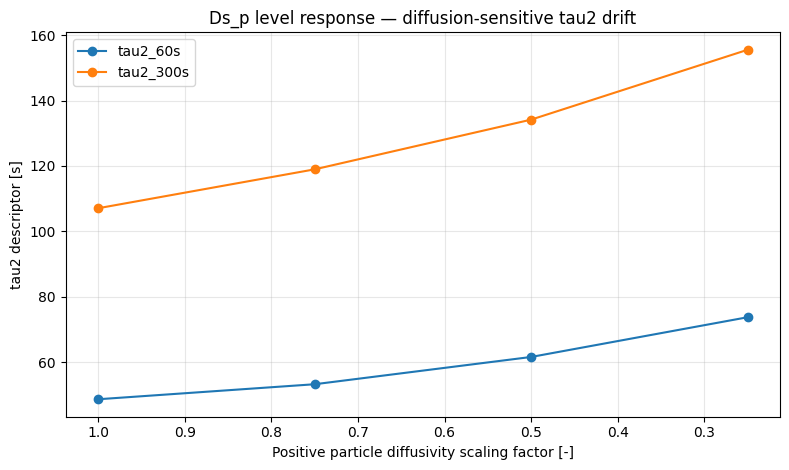

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/phaseB_soc50_Ds_p_tau2_level_response.png


In [10]:
# Cell 10 — Level-response plot for diffusion family（正极扩散扰动对 tau 的响应曲线）

plot_df = drift_table[drift_table["family"].isin(["baseline", "Ds_p"])].copy()
plot_df = plot_df.sort_values("level", ascending=False)

fig, ax1 = plt.subplots(figsize=(8, 4.8))

ax1.plot(
    plot_df["level"],
    plot_df["biexp60_tau2_s"],
    marker="o",
    label="tau2_60s",
)

ax1.plot(
    plot_df["level"],
    plot_df["biexp300_tau2_s"],
    marker="o",
    label="tau2_300s",
)

ax1.set_xlabel("Positive particle diffusivity scaling factor [-]")
ax1.set_ylabel("tau2 descriptor [s]")
ax1.set_title("Ds_p level response — diffusion-sensitive tau2 drift")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Reverse x-axis: degradation severity increases leftward
ax1.invert_xaxis()

fig.tight_layout()
fig_path = FIGURES / "phaseB_soc50_Ds_p_tau2_level_response.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

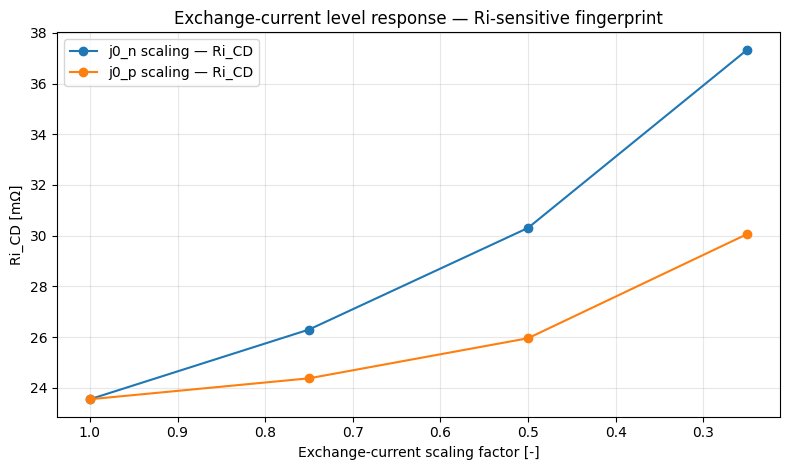

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/phaseB_soc50_j0_Ri_level_response.png


In [11]:
# Cell 11 — Level-response plot for exchange-current families（负极/正极 j0 扰动对 Ri 的响应曲线）

fig, ax = plt.subplots(figsize=(8, 4.8))

for family, label in [
    ("j0_n", "j0_n scaling"),
    ("j0_p", "j0_p scaling"),
]:
    sub = drift_table[drift_table["family"].isin(["baseline", family])].copy()
    sub = sub.sort_values("level", ascending=False)

    ax.plot(
        sub["level"],
        sub["Ri_CD_mohm"],
        marker="o",
        label=f"{label} — Ri_CD",
    )

ax.set_xlabel("Exchange-current scaling factor [-]")
ax.set_ylabel("Ri_CD [mΩ]")
ax.set_title("Exchange-current level response — Ri-sensitive fingerprint")
ax.grid(True, alpha=0.3)
ax.legend()

# Reverse x-axis: degradation severity increases leftward
ax.invert_xaxis()

fig.tight_layout()
fig_path = FIGURES / "phaseB_soc50_j0_Ri_level_response.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

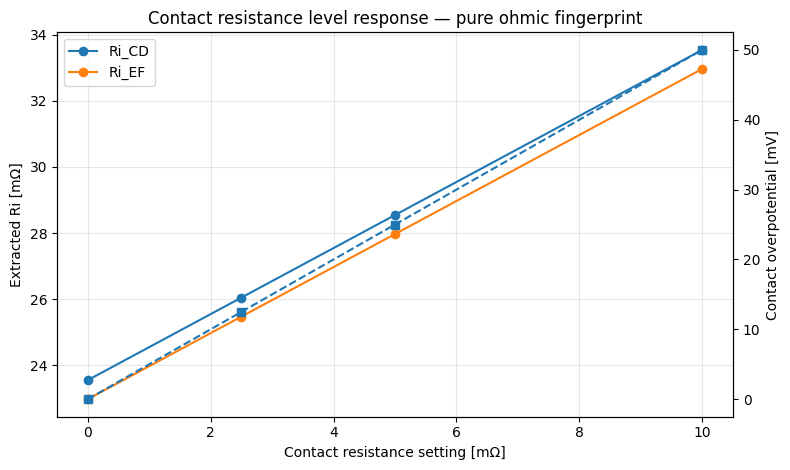

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/phaseB_soc50_contact_R_linearity_audit_corrected.png


,case,family,level,contact_R_mohm,Ri_CD_mohm,Ri_EF_mohm,contact_overpotential_absmax_mV
0,baseline,baseline,1.0000,0.0,23.545486,22.969868,0.0
10,contact_R_2p5mOhm,contact_R,0.0025,2.5,26.045486,25.469868,12.5
11,contact_R_5p0mOhm,contact_R,0.0050,5.0,28.545486,27.969868,25.0
12,contact_R_10p0mOhm,contact_R,0.0100,10.0,33.545486,32.969868,50.0


In [13]:
# Cell 12 — Contact resistance linearity audit（接触电阻对 Ri 和接触过电位的线性响应）

contact_df = drift_table[drift_table["family"].isin(["baseline", "contact_R"])].copy()

# For contact resistance family:
# baseline should be plotted at 0 mΩ, not level=1.0 × 1000.
contact_df["contact_R_mohm"] = np.where(
    contact_df["family"] == "baseline",
    0.0,
    contact_df["level"] * 1000,
)

contact_df = contact_df.sort_values("contact_R_mohm")

fig, ax1 = plt.subplots(figsize=(8, 4.8))

ax1.plot(
    contact_df["contact_R_mohm"],
    contact_df["Ri_CD_mohm"],
    marker="o",
    label="Ri_CD",
)

ax1.plot(
    contact_df["contact_R_mohm"],
    contact_df["Ri_EF_mohm"],
    marker="o",
    label="Ri_EF",
)

ax1.set_xlabel("Contact resistance setting [mΩ]")
ax1.set_ylabel("Extracted Ri [mΩ]")
ax1.set_title("Contact resistance level response — pure ohmic fingerprint")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(
    contact_df["contact_R_mohm"],
    contact_df["contact_overpotential_absmax_mV"],
    marker="s",
    linestyle="--",
    label="contact overpotential",
)

ax2.set_ylabel("Contact overpotential [mV]")

fig.tight_layout()
fig_path = FIGURES / "phaseB_soc50_contact_R_linearity_audit_corrected.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

display(contact_df[
    [
        "case",
        "family",
        "level",
        "contact_R_mohm",
        "Ri_CD_mohm",
        "Ri_EF_mohm",
        "contact_overpotential_absmax_mV",
    ]
])

In [14]:
# Cell 13 — Monotonicity audit table（扰动强度-可观测量单调性审计）

def check_monotonic_response(df, family, level_col, metric_col, expected_direction):
    """
    expected_direction:
    - "increase_with_degradation": metric should increase as degradation severity increases
    - "decrease_with_degradation": metric should decrease as degradation severity increases
    """
    sub = df[df["family"].isin(["baseline", family])].copy()

    if family == "contact_R":
        sub["severity"] = np.where(sub["family"] == "baseline", 0.0, sub["level"])
        sub = sub.sort_values("severity")
    else:
        # For multiplicative degradation levels:
        # level = 1.0 is baseline, lower level means stronger perturbation.
        sub["severity"] = 1.0 - sub["level"]
        sub = sub.sort_values("severity")

    values = sub[metric_col].values
    diffs = np.diff(values)

    if expected_direction == "increase_with_degradation":
        monotonic = bool(np.all(diffs >= -1e-9))
    elif expected_direction == "decrease_with_degradation":
        monotonic = bool(np.all(diffs <= 1e-9))
    else:
        raise ValueError("Unknown expected_direction")

    return {
        "family": family,
        "metric": metric_col,
        "expected_direction": expected_direction,
        "monotonic": monotonic,
        "values": values.tolist(),
        "diffs": diffs.tolist(),
        "n_points": len(values),
    }


monotonicity_specs = [
    ("Ds_p", "level", "biexp60_tau2_s", "increase_with_degradation"),
    ("Ds_p", "level", "biexp300_tau2_s", "increase_with_degradation"),
    ("j0_n", "level", "Ri_CD_mohm", "increase_with_degradation"),
    ("j0_n", "level", "Ri_EF_mohm", "increase_with_degradation"),
    ("j0_p", "level", "Ri_CD_mohm", "increase_with_degradation"),
    ("j0_p", "level", "Ri_EF_mohm", "increase_with_degradation"),
    ("contact_R", "level", "Ri_CD_mohm", "increase_with_degradation"),
    ("contact_R", "level", "Ri_EF_mohm", "increase_with_degradation"),
    ("contact_R", "level", "contact_overpotential_absmax_mV", "increase_with_degradation"),
]

monotonicity_rows = []

for family, level_col, metric_col, expected_direction in monotonicity_specs:
    monotonicity_rows.append(
        check_monotonic_response(
            drift_table,
            family=family,
            level_col=level_col,
            metric_col=metric_col,
            expected_direction=expected_direction,
        )
    )

monotonicity_table = pd.DataFrame(monotonicity_rows)

out_csv = DATA / "phaseB_level_scan_soc50_monotonicity_audit.csv"
monotonicity_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(monotonicity_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/phaseB_level_scan_soc50_monotonicity_audit.csv


,family,metric,expected_direction,monotonic,values,diffs,n_points
0,Ds_p,biexp60_tau2_s,increase_with_degradation,True,"[48.6983747282752, 53.28682513569187, 61.62214...","[4.588450407416673, 8.335315310339794, 12.1378...",4
1,Ds_p,biexp300_tau2_s,increase_with_degradation,True,"[107.08563534862037, 118.97169309533615, 134.1...","[11.886057746715778, 15.190406877071268, 21.34...",4
2,j0_n,Ri_CD_mohm,increase_with_degradation,True,"[23.545486057654585, 26.295121210183936, 30.30...","[2.7496351525293505, 4.011125910938862, 7.0264...",4
3,j0_n,Ri_EF_mohm,increase_with_degradation,True,"[22.96986812782915, 25.694062945343, 29.684100...","[2.7241948175138475, 3.9900377756826977, 7.011...",4
4,j0_p,Ri_CD_mohm,increase_with_degradation,True,"[23.545486057654585, 24.37137265266074, 25.953...","[0.8258865950061534, 1.5818935060229578, 4.108...",4
5,j0_p,Ri_EF_mohm,increase_with_degradation,True,"[22.96986812782915, 23.839703388319222, 25.499...","[0.8698352604900705, 1.659509465289677, 4.2601...",4
6,contact_R,Ri_CD_mohm,increase_with_degradation,True,"[23.545486057654585, 26.04548605765462, 28.545...","[2.5000000000000355, 2.4999999999999467, 4.999...",4
7,contact_R,Ri_EF_mohm,increase_with_degradation,True,"[22.96986812782915, 25.469868127829187, 27.969...","[2.5000000000000355, 2.4999999999999467, 4.999...",4
8,contact_R,contact_overpotential_absmax_mV,increase_with_degradation,True,"[0.0, 12.499999999999956, 25.00000000000002, 5...","[12.499999999999956, 12.500000000000066, 25.00...",4
